## Seminar 5. Transformer

For a little while, we'll set the generation task aside and come back to classification instead. This time we'll come back to the usual `ag_news` dataset that we've already used twice by now, and continue using it as our benchmark. Although, today we're going to use it a little bit differently...

## Let's load the data

### Hugging Face 🤗

Hugging Face is a company that develops tools and libraries for working with deep learning models, especially in the field of NLP. In addition to the company’s own developments, Hugging Face has a [hub](https://huggingface.co/docs/hub/index), where any user can upload their model, dataset, or something else. Here’s a list of the main libraries we’ll need:

1. [`transformers`](https://huggingface.co/docs/transformers/index) – contains implementations with weights for all the most popular transformer models, as well as tokenizers for them.
2. [`tokenizers`](https://huggingface.co/docs/tokenizers/index) – a library for training your own tokenizers, which almost *nobody uses directly*. It’s better to take tokenizers from `transformers`.
3. [`datasets`](https://huggingface.co/docs/datasets/index) – a library for loading and processing all datasets from the Hugging Face hub.
4. [`evaluate`](https://huggingface.co/docs/evaluate/index) – contains implementations of a huge number of metrics (possibly all of them) for evaluating model quality.

In the coming weeks, we’ll also try out:

1. [`accelerate`](https://huggingface.co/docs/accelerate/index) – a library with tricks for speeding up training and inference of models.
2. [`bitsandbytes`](https://huggingface.co/docs/bitsandbytes/index) – designed for training and applying quantized models.
3. [`peft`](https://huggingface.co/docs/peft/index) – a library with methods for Parameter-Efficient Fine-tuning.

All in all, there are a lot of libraries. Their main advantage lies in ease of use. All libraries can work together, and all classes within one library have the same interface.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm

### `datasets`


All datasets from [Hugging Face](https://huggingface.co/datasets) are avaliable for download by using just one line with [`load_dataset`](https://huggingface.co/docs/datasets/v2.19.0/en/package_reference/loading_methods#datasets.load_dataset). After that it's easy to modify them with `map` method.

In [ ]:
# ! pip3 install datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("fancyzhx/ag_news")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

### `tokenizers`

[`tokenizers`](https://huggingface.co/docs/tokenizers/index) is a library for building and training custom tokenizers from scratch. It is written in Rust (for speed) with Python bindings. In practice, most users don’t train tokenizers themselves but instead rely on pre-trained ones from `transformers`. Still, `tokenizers` provides full control over the tokenization pipeline, and we can also choose the method of tokenization (BPE, WordPiece, Unigram, etc.) for our own purposes:


In [ ]:
from transformers import BertTokenizerFast

tokenizer_fast = BertTokenizerFast.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
from functools import partial

def tokenize(tokenizer, sample):
    return tokenizer(sample['text'])

tokenized_dataset = dataset.map(
    partial(tokenize, tokenizer_fast),
    batched=True,
    num_proc=30,
    desc="Tokenization",
    batch_size=1000,
)

Tokenization (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenization (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

The function used in `map` method always should return a dict. The name of the key will become a new column's name.

For example, we can also add the paragraph lenghs:

In [ ]:
def get_len(sample):
    return {'len': [len(x) for x in sample['input_ids']]}

dataset_with_lens = tokenized_dataset.map(
    get_len,
    batched=True,
    num_proc=30,
    desc="Get length",
    batch_size=1000,
)

Get length (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Get length (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

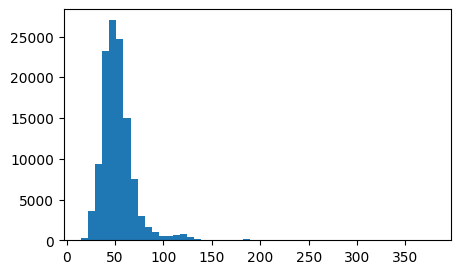

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.hist(dataset_with_lens['train']['len'], bins=50);

Sometimes it's also useful to change the data types:

In [ ]:
tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
tokenized_dataset['test'][0]

{'label': tensor(2),
 'input_ids': tensor([  101, 10069,  2005,  1056,  1050, 11550,  2044,  7566,  9209,  5052,
          3667,  2012,  6769,  2047,  8095,  2360,  2027,  2024,  1005,  9364,
          1005,  2044,  7566,  2007, 16654,  6687,  3813,  2976,  9587, 24848,
          1012,   102]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1])}

So, now let's train our own tokenizer and limit the `vocab_size`:

In [ ]:
from tokenizers import BertWordPieceTokenizer
import os

texts = dataset["train"]["text"]

tokenizer = BertWordPieceTokenizer(lowercase=True, strip_accents=True)
tokenizer.train_from_iterator(
    (t.strip() for t in texts if t is not None and t.strip()),
    vocab_size=4000,          # try 4k/8k/12k given your corpus size
    min_frequency=5,
    limit_alphabet=1000,
    wordpieces_prefix="##",
    special_tokens=["[PAD]","[UNK]","[CLS]","[SEP]","[MASK]"],
    show_progress=True,
)

out_dir = "my-bert-uncased-wp-4k"

# Create the directory if it doesn't exist
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

tokenizer.save_model(out_dir)  # writes vocab.txt (and tokenizer.json if available)

['my-bert-uncased-wp-4k/vocab.txt']

Reloading the tokenizer this way will use the version implemented on Rust, making the tokenization faster:

In [ ]:
tokenizer_fast = BertTokenizerFast.from_pretrained(out_dir, do_lower_case=True)

In [ ]:
MAX_LENGTH = 128

In [ ]:
from functools import partial

def tokenize(tokenizer, sample):
    return tokenizer(sample['text'],
                     truncation=True,
                     max_length=MAX_LENGTH,
                     )

tokenized_dataset = dataset.map(
    partial(tokenize, tokenizer_fast),
    batched=True,
    num_proc=30,
    desc="Tokenization",
    batch_size=1000,
)

tokenized_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Tokenization (num_proc=30):   0%|          | 0/120000 [00:00<?, ? examples/s]

Tokenization (num_proc=30):   0%|          | 0/7600 [00:00<?, ? examples/s]

Knowing that we have a lot of texts of different length, where a big part of them might be less than 128 tokens, we need to add paddings. Using `DataCollatorWithPadding` will make it more optimal, instead of implementing it directly while tokenization.

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer_fast,
    pad_to_multiple_of=8,
)

In [ ]:
from torch.utils.data import DataLoader

batch_size = 256
train_loader = DataLoader(tokenized_dataset['train'], batch_size, shuffle=True, num_workers=2, pin_memory=True, collate_fn=data_collator)
test_loader = DataLoader(tokenized_dataset['test'], batch_size, shuffle=False, num_workers=2, pin_memory=True, collate_fn=data_collator)

Let's take a sneak peek at what we have in the DataLoader:

In [ ]:
batch = next(iter(train_loader))

print({k: v.shape for k, v in batch.items()})

{'input_ids': torch.Size([256, 128]), 'attention_mask': torch.Size([256, 128]), 'labels': torch.Size([256])}


In [ ]:
print({k: v for k, v in batch.items()})

{'input_ids': tensor([[   2,  333, 1315,  ...,    0,    0,    0],
        [   2, 2596, 2659,  ...,    0,    0,    0],
        [   2, 2974,   10,  ...,    0,    0,    0],
        ...,
        [   2, 3381, 2871,  ...,    0,    0,    0],
        [   2,   26,  367,  ...,    0,    0,    0],
        [   2,  737,   28,  ...,    0,    0,    0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([0, 1, 0, 0, 2, 0, 2, 0, 0, 3, 1, 3, 3, 3, 3, 0, 3, 1, 1, 1, 3, 1, 2, 2,
        1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 3, 2, 2, 0, 1, 2, 0, 3, 3, 1, 0, 1, 1,
        1, 3, 2, 2, 3, 2, 2, 2, 0, 0, 2, 3, 1, 0, 1, 2, 1, 3, 3, 3, 3, 3, 2, 1,
        0, 0, 1, 3, 2, 0, 0, 3, 1, 1, 2, 3, 0, 2, 1, 1, 2, 2, 2, 2, 1, 0, 0, 2,
        1, 2, 0, 2, 0, 0, 2, 3, 0, 2, 2, 0, 0, 1, 3, 3, 2, 3, 1, 2, 1, 2, 2, 2,
        2, 1

and some constants...

In [ ]:
VOCAB_SIZE = tokenizer_fast.vocab_size
PAD_ID = tokenizer_fast.pad_token_type_id
NUM_CLASSES = 4

## Transformer architecture

Now, let's see the thing we're here for in the first place: transformers.

We are going to explain it in details, but if you want to watch other sources, we highly recommend [this](https://youtu.be/zxQyTK8quyY?si=xqZD5CsotEez9IO7) video on YouTube.

In this code we will implement only Encoders, since we perform the classification and there is no need in the AutoRegressive blocks, but those can be easily transformed from the blocks we'll have further.

### Architecture overview:

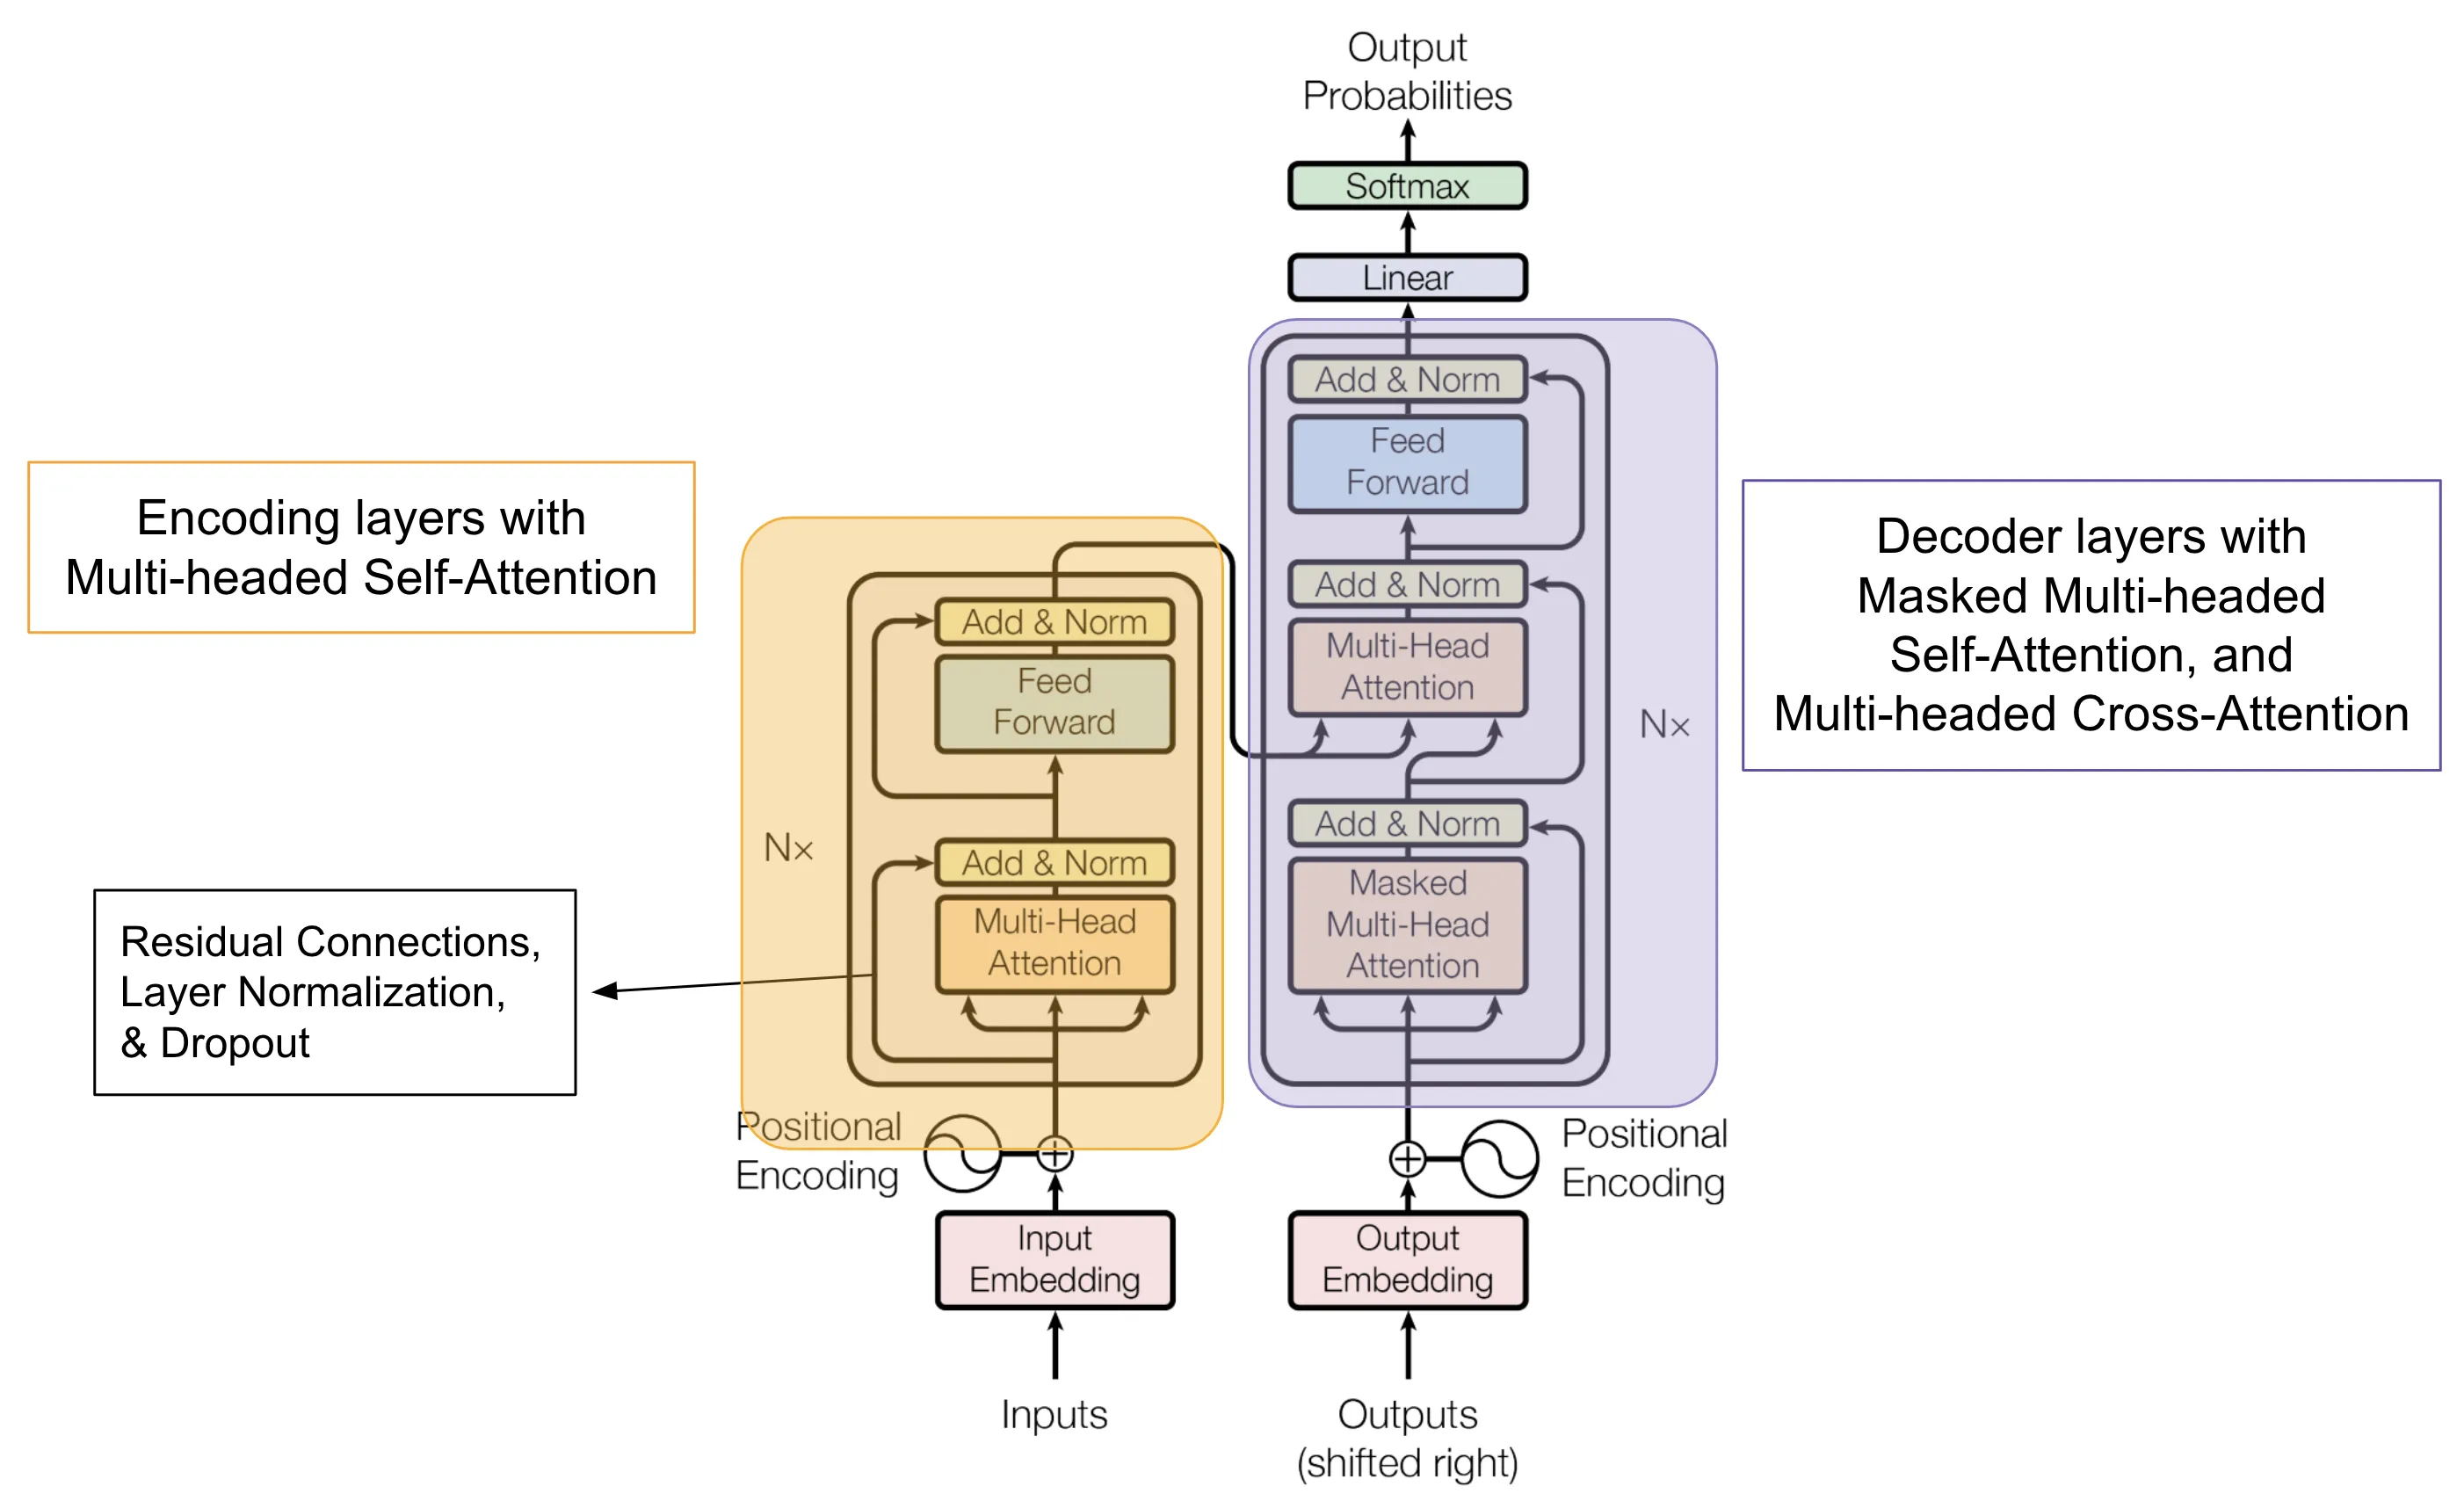

Now, we don't have any recurrence or convolution, as we used to on the previous seminars, but we still keep the `Attention` we learnt last time.

New type of architecture still follows an encoder–decoder structure, tho. The **encoder** maps an input sequence of tokens into embeddings, while the **decoder** generates an output sequence step by step, attending both to the encoder output and to the previously generated tokens.

Both encoder and decoder are composed of multiple identical layers (6 in the base model, but we'll use only 4 to be able to perform the computations).


### Positional encoding

Since our model contains no recurrence and no convolution, in order for the model to make use of the order of the sequence, we must inject some information about the relative or absolute position of the tokens in the sequence. To do so, we add "positional encodings" to the input embeddings at the bottoms of the encoder and decoder stacks.  The positional encodings have the same dimension $d_{\text{model}}$ as the embeddings, so that the two can be summed.   There are many choices of positional encodings, learned and fixed [(take a look here)](https://arxiv.org/pdf/1705.03122.pdf).

In this work, we use sine and cosine functions of different frequencies:                                                                    
$$PE_{(pos,2i)} = sin(pos / 10000^{2i/d_{\text{model}}})$$

$$PE_{(pos,2i+1)} = cos(pos / 10000^{2i/d_{\text{model}}})$$                                                                                                                                                                                                                                                        
where $pos$ is the position and $i$ is the dimension.  That is, each dimension of the positional encoding corresponds to a sinusoid.  The wavelengths form a geometric progression from $2\pi$ to $10000 \cdot 2\pi$.

In addition, we apply dropout to the sums of the embeddings and the positional encodings in both the encoder and decoder stacks.  For the base model, we use a rate of $P_{drop}=0.2$.

In [ ]:
import math
from torch import nn

class PositionalEncoder(nn.Module):

    def __init__(self, max_length, embed_dim, dropout):
        super().__init__()
        self.pos_features = torch.zeros(max_length, embed_dim)

        positions = torch.arange(0, max_length, dtype=torch.float).unsqueeze(1)
        freqs = torch.exp(torch.arange(0, embed_dim, 2, dtype=torch.float) * \
                          (-math.log(10000) / embed_dim)).unsqueeze(0)

        arguments = positions * freqs
        self.pos_features[:, 0::2] = torch.sin(arguments)
        self.pos_features[:, 1::2] = torch.cos(arguments)
        self.pos_features = self.pos_features.unsqueeze(0)
        self.pos_features = nn.Parameter(self.pos_features, requires_grad=False)
        # pos_features: (1, max_length, embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, inputs):
        outputs = inputs + self.pos_features[:, :inputs.shape[1]]
        return self.dropout(outputs)

To get more information about *relative* positional encoders, please take a look at [this](https://youtu.be/o29P0Kpobz0) video or search for RoPE: Rotary Positional Embeddings.

### Attention

![](https://jalammar.github.io/images/t/self-attention-matrix-calculation-2.png)

The core idea of attention is to compute a weighted sum of values, where the weights are determined by the similarity between queries and keys. This allows the model to “search” through the sequence and decide which parts of the input are most relevant for the current token.

Scaled dot-product attention takes as input queries $Q$, keys $K$, and values $V$, which are themselves learned **linear projections** of the input embeddings into three different spaces:

* $Q$ → query space (what we are looking for),
* $K$ → key space (what we have indexed),
* $V$ → value space (the information we retrieve).

The attention output is computed as:


$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V$$

Here $d_k$ is the dimension of the keys. The division by $\sqrt{d_k}$ prevents the dot products from growing too large, which would push the softmax into regions with very small gradients.

* The matrix $QK^{T}$ contains the similarity scores between queries and keys (the “search step”).
* The softmax normalizes these scores into probabilities (the “match strength”).
* Multiplying by $V$ produces a weighted sum of the values, retrieving the most relevant information for each query.

Dropout is applied on the attention weights before multiplication with $V$.


In [ ]:
class Attention(nn.Module):
    # Single-head attention
    def __init__(self, embed_dim, num_heads, dropout):
        super().__init__()
        attention_dim = embed_dim // num_heads

        self.WQ = nn.Linear(embed_dim, attention_dim, bias=False) # shape: (embed_dim, ???)
        self.WK = nn.Linear(embed_dim, attention_dim, bias=False) # shape WK.T: (???, embed_dim)
        self.WV = nn.Linear(embed_dim, attention_dim, bias=False) # shape: (embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (batch_size, length, embed_dim)
        # mask: (batch_size, length, length)

        # query == key == value == x_i, since it is a projection of the Embeddings
        # onto different vector spaces.

        Q = self.WQ(query)
        K = self.WK(key)
        V = self.WV(value)
        # Q, K, V: (batch_size, length, attention_dim)

        norm_factor = math.sqrt(Q.shape[-1])
        dot_products = torch.bmm(Q, K.transpose(1, 2)) / norm_factor
        # dot_products: (batch_size, length, length)

        if mask is not None:
            dot_products = dot_products.masked_fill(mask, -math.inf)

        attention_score = nn.functional.softmax(dot_products, dim=-1)
        attention = torch.bmm(self.dropout(attention_score), V)
        # attention_score: (batch_size, length, length)
        # attention: (batch_size, length, attention_dim)

        return attention, attention_score


class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout):
        super(MultiHeadAttention, self).__init__()

        assert embed_dim % num_heads == 0
        self.attention_heads = nn.ModuleList([Attention(embed_dim, num_heads, dropout)
                                              for _ in range(num_heads)])

        self.linear = nn.Linear(embed_dim, embed_dim, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # query, key, value: (batch_size, length, embed_dim)
        # mask: (batch_size, length, length)
        attentions, attention_scores = [], []

        for head in self.attention_heads:
            attention, attention_score = head(query, key, value, mask)
            attentions += [attention]
            attention_scores += [attention_score]

        attentions = torch.cat(attentions, dim=-1)
        attention_scores = torch.stack(attention_scores, dim=-1)
        # attentions: (batch_size, length, embed_dim)
        # attention_scores: (batch_size, length, length, num_heads)

        outputs = self.linear(attentions)
        outputs = self.dropout(outputs)
        # outputs: (batch_size, length, embed_dim)

        return outputs, attention_scores

In [ ]:
def create_padding_mask(tokens, pad_idx=PAD_ID):
    # tokens: (batch_size, length)
    length = tokens.shape[-1]
    padding_mask = (tokens == pad_idx)
    padding_mask = padding_mask.unsqueeze(1).repeat(1, length, 1)
    # padding_mask: (batch_size, length, length)

    return padding_mask

Each encoder layer contains two sub-layers: a multi-head self-attention mechanism and a position-wise fully connected feed-forward network. Each decoder layer has three sub-layers: a masked multi-head self-attention mechanism, a multi-head attention mechanism over the encoder’s output, and a feed-forward network.

Residual connections are used around each sub-layer, followed by layer normalization. To prevent overfitting, dropout is applied at various points within the model. The hidden size of all sub-layers and embeddings is $d_{\text{model}} = 512$ for the base model.

In [ ]:
class TransformerLayer(nn.Module):
    def __init__(self, embed_dim, fc_dim, num_heads, dropout):
        super().__init__()
        self.self_attention = MultiHeadAttention(embed_dim, num_heads, dropout)
        self.feedforward = nn.Sequential(
            nn.Linear(embed_dim, fc_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, inputs, mask):
        attention, attention_score = self.self_attention(query=inputs, key=inputs,
                                                         value=inputs, mask=mask)
        outputs = inputs + attention
        outputs = self.norm1(outputs)
        outputs = outputs + self.feedforward(outputs)
        outputs = self.norm2(outputs)
        return outputs, attention_score


class Transformer(nn.Module):
    def __init__(self, vocab_size, max_length, num_classes,
                 embed_dim, fc_dim, num_heads, num_layers, dropout):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoder = PositionalEncoder(max_length, embed_dim, dropout)
        self.layers = nn.ModuleList([TransformerLayer(embed_dim, fc_dim, num_heads, dropout) \
                                     for _ in range(num_layers)])
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, tokens):
        # source: (batch_size, length)
        embeds = self.embedding(tokens) * math.sqrt(self.embed_dim)
        outputs = self.pos_encoder(embeds)
        # outputs: (batch_size, length, embed_dim)

        padding_mask = create_padding_mask(tokens)
        attention_scores = []
        for layer in self.layers:
            outputs, attention_score = layer(outputs, padding_mask)
            attention_scores += [attention_score]
        attention_scores = torch.stack(attention_scores, dim=-1)
        # outputs: (batch_size, length, embed_dim)
        # attentions_scores: (batch_size, length, embed_dim, num_heads, num_layers)

        mask = (tokens != PAD_ID).to(torch.float).detach() #[True, True, False]
        lengths = mask.sum(dim=1).detach()
        outputs = (outputs * mask.unsqueeze(2)).sum(dim=1) / lengths.unsqueeze(1)
        # outputs: (batch_size, embed_dim)

        logits = self.classifier(outputs)
        # logits: (batch_size, num_classes)

        return logits, attention_scores

In [ ]:
from IPython.display import clear_output

def plot_losses(train_losses, test_losses, train_accuracies, test_accuracies):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_accuracies) + 1), train_accuracies, label='train')
    axs[1].plot(range(1, len(test_accuracies) + 1), test_accuracies, label='test')
    axs[1].set_ylabel('accuracy')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = Transformer(vocab_size=VOCAB_SIZE, max_length=MAX_LENGTH, num_classes=NUM_CLASSES,
                    embed_dim=32, fc_dim=32, num_heads=4, num_layers=4, dropout=0.2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [ ]:
print(model)

Transformer(
  (embedding): Embedding(4000, 32)
  (pos_encoder): PositionalEncoder(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (layers): ModuleList(
    (0-3): 4 x TransformerLayer(
      (self_attention): MultiHeadAttention(
        (attention_heads): ModuleList(
          (0-3): 4 x Attention(
            (WQ): Linear(in_features=32, out_features=8, bias=False)
            (WK): Linear(in_features=32, out_features=8, bias=False)
            (WV): Linear(in_features=32, out_features=8, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (linear): Linear(in_features=32, out_features=32, bias=False)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (feedforward): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ReLU()
        (2): Dropout(p=0.2, inplace=False)
        (3): Linear(in_features=32, out_features=32, bias=True)
        (4): Dropout(p=0.2, inplace=False)
      )
      (norm

In [ ]:
sum(param.numel() for param in model.parameters())

157572

## Training

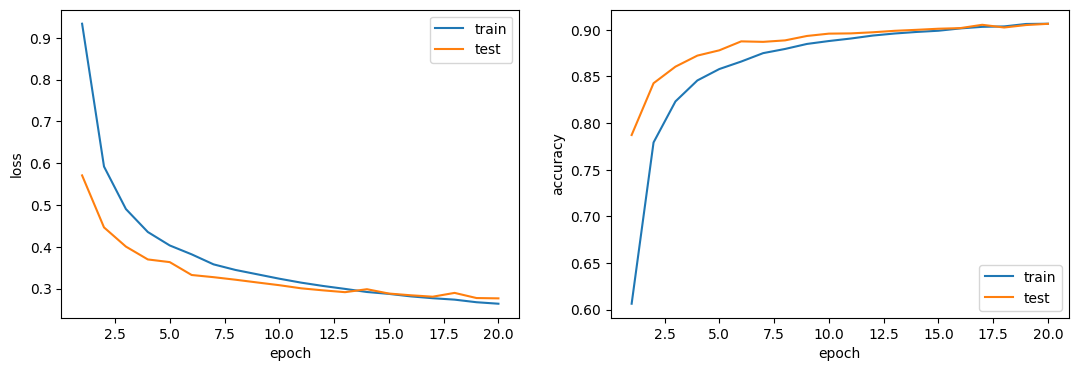

Best test accuracy: 0.9064473684210527


In [ ]:
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []
num_epochs = 20

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss, running_accuracy = 0.0, 0.0
    for batch in tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}'):
        optimizer.zero_grad()
        tokens = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        logits, _ = model(tokens)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * tokens.shape[0]
        running_accuracy += (logits.argmax(dim=1) == labels).sum().item()


    train_losses += [running_loss / len(train_loader.dataset)]
    train_accuracies += [running_accuracy / len(train_loader.dataset)]

    model.eval()
    running_loss, running_accuracy = 0.0, 0.0
    for batch in tqdm(test_loader, desc=f'Testing {epoch}/{num_epochs}'):
        tokens = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)

        with torch.no_grad():
            logits, _ = model(tokens)
            loss = criterion(logits, labels)

        running_loss += loss.item() * tokens.shape[0]
        running_accuracy += (logits.argmax(dim=1) == labels).sum().item()

    test_losses += [running_loss / len(test_loader.dataset)]
    test_accuracies += [running_accuracy / len(test_loader.dataset)]
    plot_losses(train_losses, test_losses, train_accuracies, test_accuracies)

print(f'Best test accuracy: {max(test_accuracies)}')

## Visualizing attention scores

One way to better understand how the Transformer works is to visualize the **attention scores**. These scores come from the `attention_scores` part of the class we've wrote.



In [ ]:
for batch in train_loader:
    tokens = batch["input_ids"]
    labels = batch["labels"]
    break

In [ ]:
labels[:1]

tensor([0])

In [ ]:
tokens.shape

torch.Size([256, 128])

In [ ]:
tokens = tokens[:1]
tokens

tensor([[   2,  947, 3760,  796,  108,  627,  409, 1213,  250,   34,  947, 3760,
          237,  796,  132,  514, 2427, 2113,  131,  459,  162,  102, 1730, 1567,
          656,  359,   75,   60, 2270,  828,  242, 1838,  363,  111,  211,  367,
         3684,  375,  186, 1452,  743, 1099,   14,   34, 1189, 3085, 2945,   16,
            3,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]])

In [ ]:
(tokens != 0).sum()

tensor(49)

In [ ]:
tokens = tokens[:, :(tokens != 0).sum().item()]

In [ ]:
with torch.no_grad():
    logits, scores = model(tokens.to(device))

In the plot below, each square represents the attention distribution for one head in one layer of the model. The color intensity shows the weight assigned to each key when producing the weighted sum of values.

Different heads can specialize in different patterns: some may focus on local dependencies (e.g., neighboring words), while others capture long-range relationships (e.g., subject–verb agreement).

In lower layers, attention is often sparse and concentrated on specific positions, while in deeper layers, the patterns become more diffuse and global, integrating information across the whole sequence.

By inspecting these heatmaps, sometimes we can literally “see” the model’s search process: queries (rows) scanning across all possible keys (columns) to find relevant information. Although, don't be fooled by those heatmaps: often they are not that easy to decode and find the pattern in the dependencies.

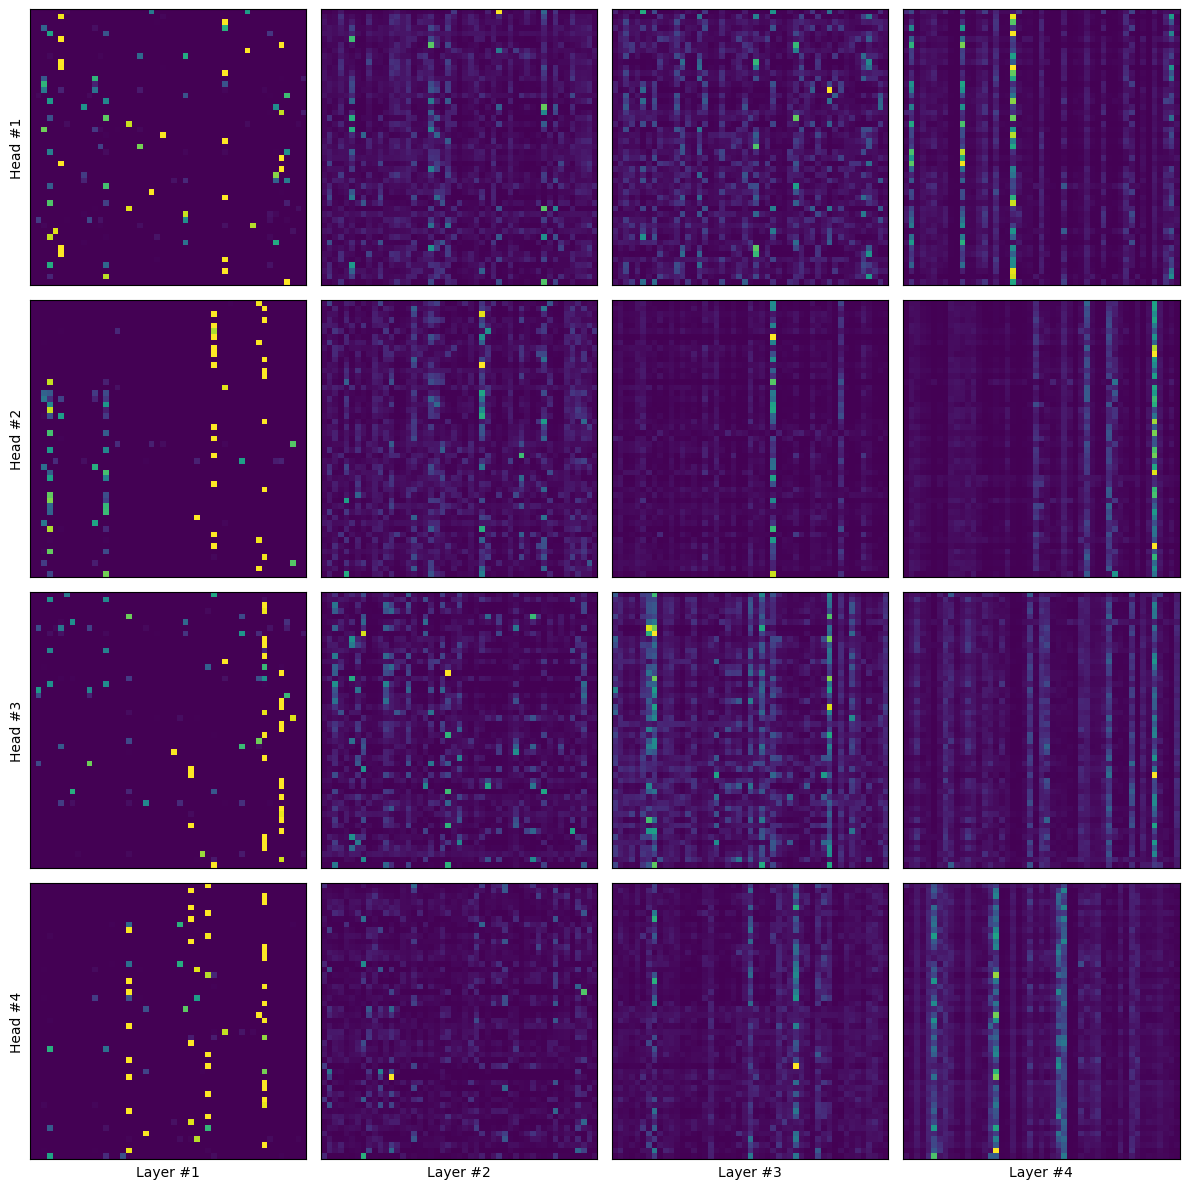

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))

for i in range(4):
    axs[i, 0].set_ylabel(f'Head #{i + 1}')
    axs[-1, i].set_xlabel(f'Layer #{i + 1}')
    for j in range(4):
        axs[i, j].imshow(scores[0, ..., i, j].cpu().numpy())
        axs[i, j].grid()
        axs[i, j].xaxis.set_ticks([])
        axs[i, j].yaxis.set_ticks([])

plt.tight_layout()
plt.show()

In [ ]:
tokens.squeeze().cpu().numpy()

array([   2,  947, 3760,  796,  108,  627,  409, 1213,  250,   34,  947,
       3760,  237,  796,  132,  514, 2427, 2113,  131,  459,  162,  102,
       1730, 1567,  656,  359,   75,   60, 2270,  828,  242, 1838,  363,
        111,  211,  367, 3684,  375,  186, 1452,  743, 1099,   14,   34,
       1189, 3085, 2945,   16,    3])

In [ ]:
words = [tokenizer_fast.convert_ids_to_tokens([token])[0] for token in tokens.squeeze().cpu().numpy()]

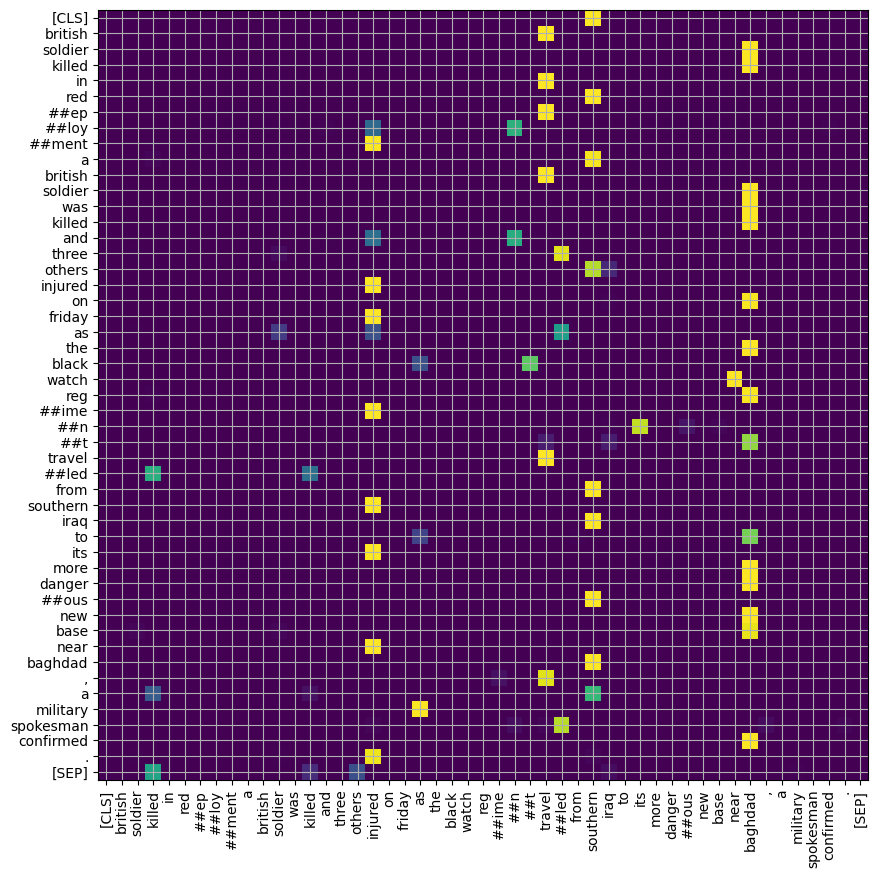

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

plt.imshow(scores[0, ..., 3, 0].cpu().numpy())
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=90)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)

plt.grid()
plt.show()